In [203]:
# !pip install h5py
# !pip install umap-learn
#!pip install torch

In [204]:
import numpy as np
import pandas as pd
import h5py
import torch
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, max_error, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import zscore
import umap.umap_ as umap
import matplotlib.cm as cm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

### Analysis of main dataset ("data/data_for_ml.h5")

In [205]:
fn="data/data_for_ml.h5"

In [206]:
#open the file in read mode
with h5py.File('data/data_for_ml.h5', 'r') as f:  
    keys = f.keys() #gives list of the names used in the file

    for key in keys:
        print(key)


DCIR
Dynamic_PsRP_1_1C
Dynamic_PsRP_1_C
Dynamic_PsRP_2_1C
Dynamic_PsRP_2_C
Static_HPPC
Static_PsRP_1
Static_PsRP_2_Chg
Static_PsRP_2_Dis
Static_Rapid


In [207]:
# loading specific data file 
data = pd.read_hdf(fn, key="Dynamic_PsRP_1_1C") # fn = file name and key= specific column we want to open
data

,soc,direction,voltage_0.0s,voltage_1.0s,voltage_2.0s,voltage_3.0s,voltage_4.0s,voltage_5.0s,voltage_6.0s,voltage_7.0s,...,Charge depleting cycle charge throughput,Charge sustaining cycle charge efficiency,Post C/10 charge relaxation fit MSE,Post C/5 charge relaxation fit MSE,Post C/3 charge relaxation fit MSE,Post P/3 charge relaxation fit MSE,Post C/2 charge relaxation fit MSE,Post 1C charge relaxation fit MSE,Thickness growth,Volume growth
0,0.011132,charge,6.799,7.092,7.119,7.142,7.163,6.624,6.608,6.599,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
1,0.172361,charge,7.966,8.200,8.209,8.216,8.222,7.760,7.749,7.742,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
2,0.333591,charge,8.126,8.341,8.350,8.357,8.363,7.936,7.925,7.917,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
3,0.494596,charge,8.288,8.411,8.411,8.410,8.411,8.098,8.089,8.082,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
4,0.644375,charge,8.387,8.408,8.409,8.410,8.410,8.192,8.183,8.177,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4346,0.474158,discharge,3.195,3.289,3.298,3.305,3.310,3.253,3.251,3.251,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4347,0.387823,discharge,3.178,3.276,3.287,3.295,3.300,3.243,3.241,3.240,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4348,0.301488,discharge,3.151,3.253,3.267,3.276,3.282,3.225,3.222,3.221,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4349,0.215153,discharge,3.103,3.213,3.232,3.244,3.253,3.195,3.192,3.191,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN


### Creating New Dataset with Desired Featured and Targeted Variables 

"""
==========================
##### For this data set, I am choosing

Feature (X) Variables (Inputs to the model):

            soc
            
            direction_num (numeric version of direction)
            
            All voltage_ns* columns (voltage_0.0s … voltage_120.0s)
            
            All current_ns* columns (current_0.0s … current_120.0s)
            
            temperature_ambient
            
          (Interested in Thickness growth, Volume growth but they have hundereds of missing values. So, make it simpler, initially I decided not to include)

Target (y) Variables (trying to predict):
            
            C/10 discharge capacity
            
            C/5 discharge capacity
            
            C/3 discharge capacity
            
            C/2 discharge capacity
            
            1C discharge capacity
            
            P/3 discharge capacity
==========================

#### """


In [208]:
# making the direction column catorical to numerical 
data['direction_num'] = data['direction'].map({'charge': 1, 'discharge': 0})
print(data['direction_num'])


0       1
1       1
2       1
3       1
4       1
       ..
4346    0
4347    0
4348    0
4349    0
4350    0
Name: direction_num, Length: 4351, dtype: int64


Our initial dataset (data) had two catergorical column, direction and cell_id. To make it easier for the analysis, I decided to make the direction column categorical to numerical. Here, charge = 1 and discharge = 0. And for the cell_id, I decided it keep it as categorical for now. 

In [209]:
# The dataset contained multiple cell_id values corresponding to the same cell type. To group them accordingly, I created a new column 
# called cell_type by extracting the shared identifier from each cell_id.
data['cell_type'] = data['cell_id'].astype(str).str[0]
print(data['cell_type'])

0       B
1       B
2       B
3       B
4       B
       ..
4346    D
4347    D
4348    D
4349    D
4350    D
Name: cell_type, Length: 4351, dtype: object


In [210]:
# Creating new data frame (new_data) combining all the featured (soc, direction_num (numeric version of direction), All voltage_ns* columns 
# (voltage_0.0s … voltage_120.0s), All current_ns* columns (current_0.0s … current_120.0s), temperature_ambient, cell_type (grouped by cell_id) AND 
# targeted variables (C/10 discharge capacity, C/5 discharge capacity, C/3 discharge capacity, C/2 discharge capacity, 1C discharge capacity, 
# P/3 discharge capacity)
######################################################################################
# List of columns dropping
cols_to_drop = [
    'cell_id',
    'Unnamed: 0',
    'measurement_id',
    'direction',
    'Charge depleting cycle charge throughput',
    'Charge sustaining cycle charge efficiency',
    'Post C/10 charge relaxation fit MSE',
    'Post C/5 charge relaxation fit MSE',
    'Post C/3 charge relaxation fit MSE',
    'Post P/3 charge relaxation fit MSE',
    'Post C/2 charge relaxation fit MSE',
    'Post 1C charge relaxation fit MSE',
    'Thickness growth',
    'Volume growth']

# Creating a new DataFrame without those columns
new_data = data.drop(columns=cols_to_drop)

# Check the shape and first few rows
print(new_data.shape)
print(new_data.head())

(4351, 252)
        soc  voltage_0.0s  voltage_1.0s  voltage_2.0s  voltage_3.0s  \
0  0.011132         6.799         7.092         7.119         7.142   
1  0.172361         7.966         8.200         8.209         8.216   
2  0.333591         8.126         8.341         8.350         8.357   
3  0.494596         8.288         8.411         8.411         8.410   
4  0.644375         8.387         8.408         8.409         8.410   

   voltage_4.0s  voltage_5.0s  voltage_6.0s  voltage_7.0s  voltage_8.0s  ...  \
0         7.163         6.624         6.608         6.599         6.592  ...   
1         8.222         7.760         7.749         7.742         7.737  ...   
2         8.363         7.936         7.925         7.917         7.911  ...   
3         8.411         8.098         8.089         8.082         8.076  ...   
4         8.410         8.192         8.183         8.177         8.172  ...   

   current_120.0s  temperature_ambient  C/10 discharge capacity  \
0          13

##### <span style ="color:darkblue">Initial dataset (data) had 4351 rows × 264 columns and the new dataset (new_data) have 4351 rows × 252 columns</span>

In [211]:
# Checking all the columns name
# print(new_data.columns.tolist())

In [212]:
# data type summery
dtype_counts = new_data.dtypes.value_counts()
print(dtype_counts)
# Get all columns that are object type
object_cols = new_data.select_dtypes(include='object').columns
print(object_cols.tolist())

float64    250
int64        1
object       1
Name: count, dtype: int64
['cell_type']


# Creating tables based on Cell types

In [213]:
# Getting unique cell types
unique_types = new_data['cell_type'].unique()
print(f"Unique cell types: {unique_types}")

# Counting how many unique types there are
count_types = new_data['cell_type'].nunique()
print(f"Number of unique cell_type values: {count_types}")

# Counting how many rows belong to each cell_type
type_counts = new_data['cell_type'].value_counts()
print("Counts per cell_type:")
print(type_counts)

Unique cell types: ['B' 'A' 'C' 'D']
Number of unique cell_type values: 4
Counts per cell_type:
cell_type
C    1764
D    1300
A     938
B     349
Name: count, dtype: int64


In [214]:
# Creating separate datasets for each cell_type
# new_data_A = new_data[new_data['cell_type'] == 'A']
# new_data_B = new_data[new_data['cell_type'] == 'B']
new_data_C = new_data[new_data['cell_type'] == 'C']
new_data_D = new_data[new_data['cell_type'] == 'D']
# Verifying that the number of rows for each cell_type matches the original dataset
# print(len(new_data_A), len(new_data_B), len(new_data_C), len(new_data_D));
print(new_data_C);
# print(new_data_D)

           soc  voltage_0.0s  voltage_1.0s  voltage_2.0s  voltage_3.0s  \
1287  0.008503         3.082         3.130         3.140         3.149   
1288  0.110753         3.550         3.585         3.586         3.587   
1289  0.213004         3.626         3.660         3.661         3.663   
1290  0.315254         3.687         3.720         3.721         3.722   
1291  0.417505         3.723         3.756         3.757         3.758   
...        ...           ...           ...           ...           ...   
3046  0.605694         3.653         3.845         3.852         3.858   
3047  0.480204         3.567         3.763         3.770         3.775   
3048  0.354714         3.496         3.694         3.701         3.706   
3049  0.229224         3.423         3.624         3.632         3.637   
3050  0.103734         3.259         3.472         3.483         3.492   

      voltage_4.0s  voltage_5.0s  voltage_6.0s  voltage_7.0s  voltage_8.0s  \
1287         3.158         3.082 

# Analysis for Cell C 

In [215]:
# Non-numeric columns can't be used for correlation analysis, so I filtered the dataset to include only numeric features.
# Creating a new DataFrame with numeric columns only for Cell C

numeric_C = new_data_C.select_dtypes(include=['number'])

# for col in numeric_C.columns:
#     print(col)

# Checking the result
# print(numeric_C.head())
# data type summery
dtype_counts = numeric_C.dtypes.value_counts()
print(dtype_counts)
print(numeric_C.shape)

float64    250
int64        1
Name: count, dtype: int64
(1764, 251)


In [216]:
# Cheking summary (mean, std, median, min, max, and quartiles) for Cell C dataset
summary = numeric_C.describe(percentiles=[0.25, 0.5, 0.75]).T
summary = summary[['mean','std', 'max','min', '25%', '50%', '75%']]

print(summary.head())

                  mean       std       max       min      25%       50%  \
soc           0.489315  0.293624  0.991591  0.001119  0.23073  0.485214   
voltage_0.0s  3.712728  0.275675  4.201000  2.695000  3.56200  3.711000   
voltage_1.0s  3.790042  0.264581  4.201000  2.794000  3.64800  3.785000   
voltage_2.0s  3.794489  0.263281  4.201000  2.818000  3.65200  3.787000   
voltage_3.0s  3.797971  0.261869  4.201000  2.840000  3.65500  3.789000   

                   75%  
soc           0.744399  
voltage_0.0s  3.911000  
voltage_1.0s  3.992250  
voltage_2.0s  3.999000  
voltage_3.0s  4.003000  


#### creating two new datasets from numeric_C

One with all voltage columns and temperature_ambient
and another with all voltage columns and soc

In [217]:
# First, identifing all voltage columns
voltage_columns = [col for col in numeric_C.columns if col.startswith('voltage_')]

# Dataset 1: Voltage columns + temperature_ambient
voltage_temp_C = numeric_C[voltage_columns + ['temperature_ambient']]

# Dataset 2: Voltage columns + soc
voltage_soc_C = numeric_C[voltage_columns + ['soc']]


In [218]:
# print(voltage_temp_C.shape)
# print(voltage_temp_C.head())

In [219]:
# print(voltage_soc_C.shape)
# print(voltage_soc_C.head())

#### Linear Regression Model - (voltage + temperature)

In [220]:

# Defining features and target
voltage_columns = [col for col in voltage_temp_C.columns if col.startswith('voltage_')]
X = voltage_temp_C[voltage_columns]
y = voltage_temp_C['temperature_ambient']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)



print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, lr_preds))
print("R² Score:", r2_score(y_test, lr_preds))


Linear Regression:
MSE: 138.43917535795188
R² Score: -0.002627272404011949


#### Random Forest Model - (voltage + temperature)

In [221]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


print("\nRandom Forest:")
print("MSE:", mean_squared_error(y_test, rf_preds))
print("R² Score:", r2_score(y_test, rf_preds))



Random Forest:
MSE: 79.65193640226629
R² Score: 0.42313146889086195


#### True vs Predicted (Random Forest Model - (voltage + temperature))

In [222]:
# # Creating DataFrame for plotting
# rf_results_df = pd.DataFrame({
#     'True Temperature': y_test.reset_index(drop=True),
#     'Predicted Temperature': rf_preds})

# # Scatter plot
# plt.figure(figsize=(8, 6))
# sns.scatterplot(data=rf_results_df, x='True Temperature', y='Predicted Temperature', alpha=0.6)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
# plt.title('True vs Predicted - Random Forest Model (voltage + temperature)')
# plt.xlabel('True Temperature')
# plt.ylabel('Predicted Temperature')
# plt.tight_layout()
# plt.show()


In [223]:
# Recreating the full feature set (voltage + temperature) for indexing 
X_full = voltage_temp_C.copy()

# Splitting again to get matching indices
X_train_full, X_test_full, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

# Now extracingt temperature_ambient from X_test_full
temperature = X_test_full['temperature_ambient'].reset_index(drop=True)

# Creating DataFrame for plotting
rf_results_df = pd.DataFrame({
    'True Temperature': y_test.reset_index(drop=True),
    'Predicted Temperature': rf_preds,
    'Temperature Ambient': temperature})


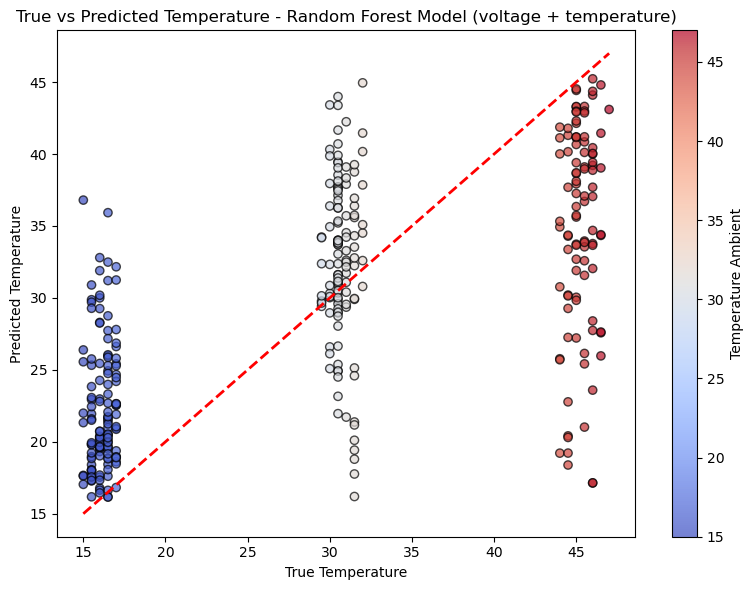

In [224]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(rf_results_df['True Temperature'],
    rf_results_df['Predicted Temperature'],
    c=rf_results_df['Temperature Ambient'],
    cmap='coolwarm',
    edgecolor='k',
    alpha=0.7)

plt.plot(
    [rf_results_df['True Temperature'].min(), rf_results_df['True Temperature'].max()],
    [rf_results_df['True Temperature'].min(), rf_results_df['True Temperature'].max()],
    'r--', lw=2)

plt.title('True vs Predicted Temperature - Random Forest Model (voltage + temperature)')
plt.xlabel('True Temperature')
plt.ylabel('Predicted Temperature')

cbar = plt.colorbar(scatter)
cbar.set_label('Temperature Ambient')

plt.tight_layout()
plt.show()


#### Residual Plot (Random Forest Model - (voltage + temperature))

In [225]:
# # Calculating residuals
# residuals = y_test.reset_index(drop=True) - rf_preds

# # Residual plot
# plt.figure(figsize=(8, 6))
# sns.scatterplot(x=rf_preds, y=residuals, alpha=0.6)
# plt.axhline(0, color='red', linestyle='--')
# plt.title('Residuals plot - Random Forest Model (voltage + temperature)')
# plt.xlabel('Predicted Temperature')
# plt.ylabel('Residuals')
# plt.tight_layout()
# plt.show()


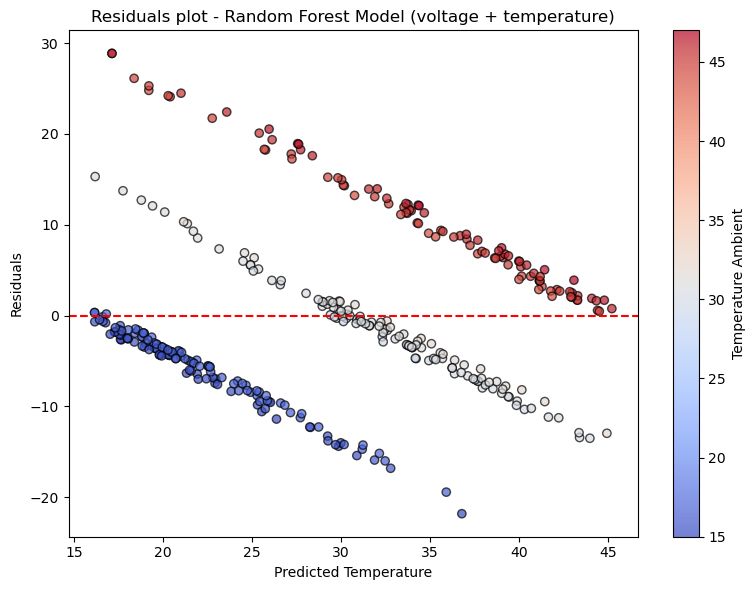

In [226]:
# Calculating residuals
residuals = y_test.reset_index(drop=True) - rf_preds

# Extracting temperature_ambient from X_test_full
temperature = X_test_full['temperature_ambient'].reset_index(drop=True)

# Creating DataFrame for residual plot
residuals_df = pd.DataFrame({
    'Predicted Temperature': rf_preds,
    'Residuals': residuals,
    'Temperature Ambient': temperature})

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    residuals_df['Predicted Temperature'],
    residuals_df['Residuals'],
    c=residuals_df['Temperature Ambient'],
    cmap='coolwarm',
    edgecolor='k',
    alpha=0.7)

plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals plot - Random Forest Model (voltage + temperature)')
plt.xlabel('Predicted Temperature')
plt.ylabel('Residuals')

cbar = plt.colorbar(scatter)
cbar.set_label('Temperature Ambient')

plt.tight_layout()
plt.show()


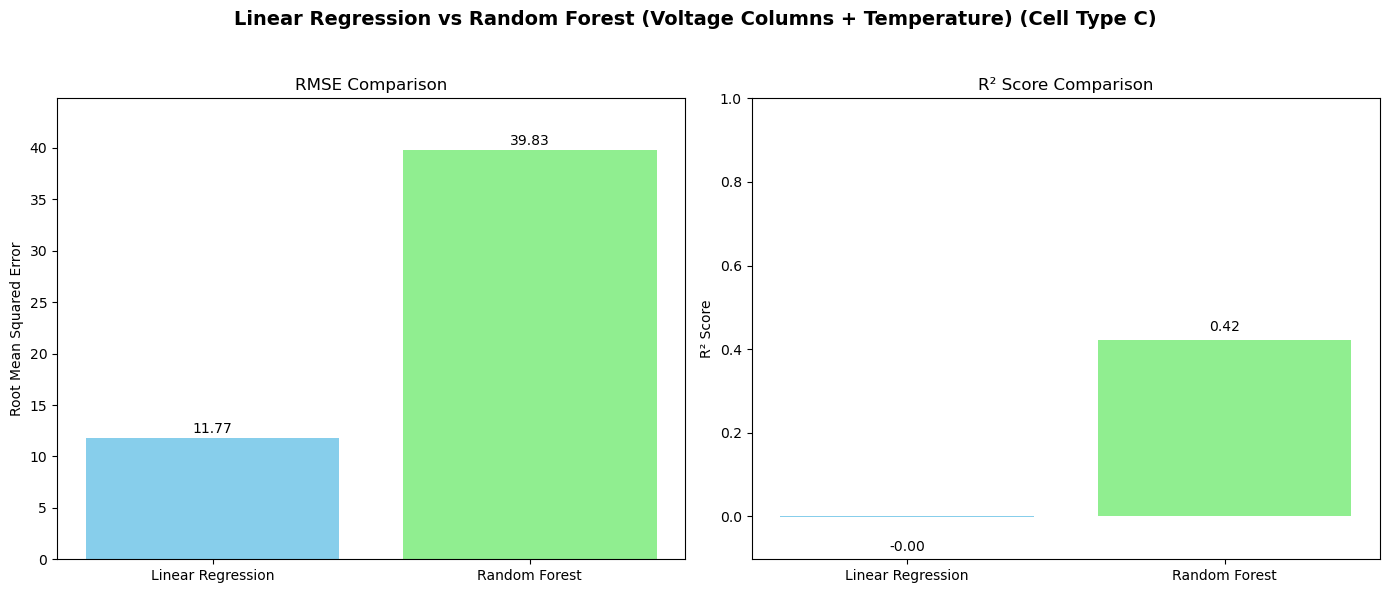

In [227]:
# Model names
models = ['Linear Regression', 'Random Forest']

# RMSE values (square root of MSE)
rmse_values = [138.43917535795188**0.5, 79.65193640226629*0.5]

# R² values
r2_values = [-0.0026, 0.4231]

# Colors for each bar
colors = ['skyblue', 'lightgreen']

# Creating subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Linear Regression vs Random Forest (Voltage Columns + Temperature) (Cell Type C)', fontsize=14, fontweight='bold')

#  Plot 1: RMSE 
bars1 = axes[0].bar(models, rmse_values, color=colors)
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('Root Mean Squared Error')
axes[0].set_ylim(0, max(rmse_values) + 5)

# Adding value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{height:.2f}", ha='center', fontsize=10)

#  Plot 2: R² Score 
bars2 = axes[1].bar(models, r2_values, color=colors)
axes[1].set_title('R² Score Comparison')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(min(r2_values) - 0.1, 1)

# Adding value labels
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, height + 0.02 if height >= 0 else height - 0.08,
                 f"{height:.2f}", ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()

#### PCA 

In [228]:
# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fitting PCA to retain 95% of variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Number of components chosen:", pca.n_components_)
print("Explained variance ratio:", pca.explained_variance_ratio_)


Number of components chosen: 2
Explained variance ratio: [0.9496088 0.0470125]


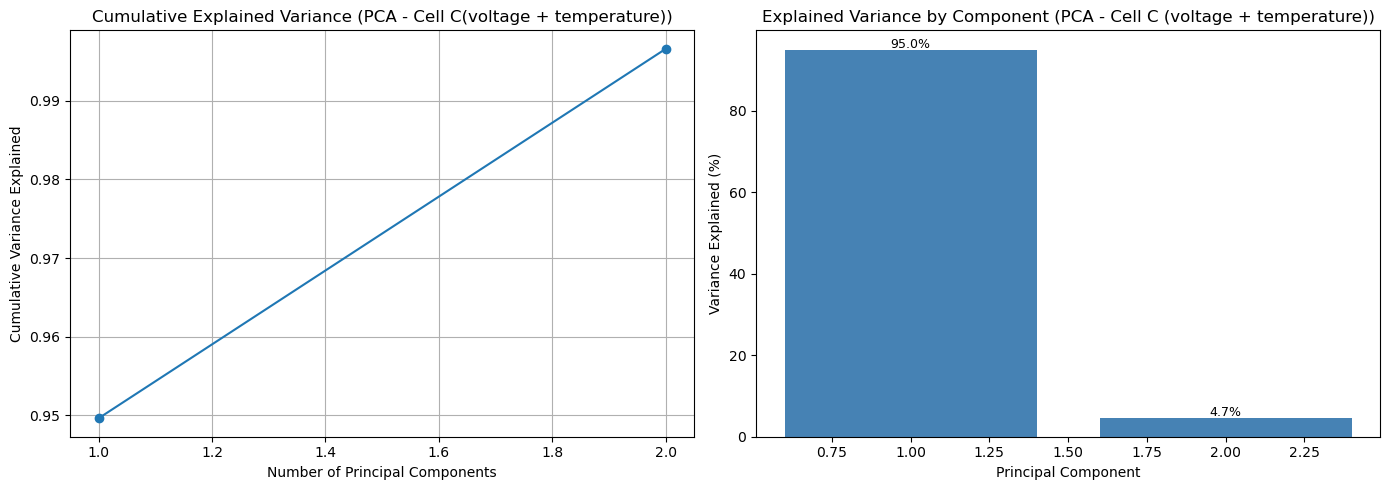

In [229]:

# Geting explained variance ratios from PCA fitted on training data
explained_var = pca.explained_variance_ratio_

# Creating subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative explained variance (line plot)
axes[0].plot(range(1, len(explained_var) + 1), np.cumsum(explained_var), marker='o', linestyle='-')
axes[0].set_title('Cumulative Explained Variance (PCA - Cell C(voltage + temperature))')
axes[0].set_xlabel('Number of Principal Components')
axes[0].set_ylabel('Cumulative Variance Explained')
axes[0].grid(True)

# Plot 2: Individual explained variance (bar plot)
axes[1].bar(range(1, len(explained_var) + 1), explained_var * 100, color='steelblue')
axes[1].set_title('Explained Variance by Component (PCA - Cell C (voltage + temperature))')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained (%)')

# Adding percentage labels on top of bars
for i, v in enumerate(explained_var * 100, start=1): axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


#### Linear Regression on PCA-transformed data

In [230]:

# Linear Regression on PCA-transformed data
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)

print("Linear Regression (PCA):")
print("MSE:", mean_squared_error(y_test, y_pred_pca))
print("R² Score:", r2_score(y_test, y_pred_pca))


Linear Regression (PCA):
MSE: 139.86340058786348
R² Score: -0.012942033770244166


#### Dummy Regressor

In [231]:
from sklearn.dummy import DummyRegressor

# Training Dummy Regressor (predicts the mean of y_train)
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

# Predictting on test set
y_pred_dummy = dummy.predict(X_test)

# Evaluating
mse_dummy = mean_squared_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mse_dummy)
r2_dummy = r2_score(y_test, y_pred_dummy)

print("Dummy Regressor (Mean Strategy)")
print("RMSE:", rmse_dummy)
print("R² Score:", r2_dummy)


Dummy Regressor (Mean Strategy)
RMSE: 11.775997471784459
R² Score: -0.004328801983158215


In [ ]:
# RAndom Forest Model using PCA

#### comparsion between all the models for (voltage + temperature)

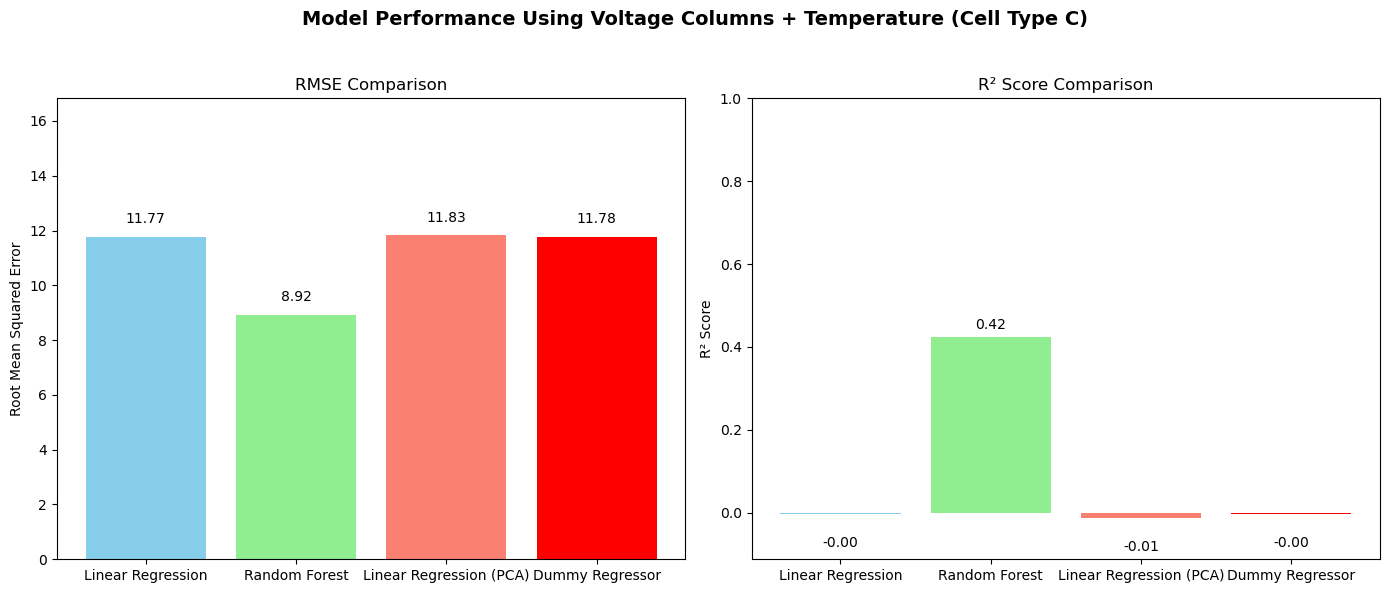

In [232]:

# Model names
models = ['Linear Regression', 'Random Forest', 'Linear Regression (PCA)', 'Dummy Regressor']

# RMSE values (square root of MSE)
rmse_values = [138.43917535795188**0.5, 79.65193640226629**0.5,  139.86340058786348**0.5, 11.775997471784459 ]

# R² values
r2_values = [-0.0026, 0.4231, -0.0129, -0.0043 ]

# Colors for each bar
colors = ['skyblue', 'lightgreen', 'salmon', 'red']

# Creating subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Performance Using Voltage Columns + Temperature (Cell Type C)', fontsize=14, fontweight='bold')

#  Plot 1: RMSE 
bars1 = axes[0].bar(models, rmse_values, color=colors)
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('Root Mean Squared Error')
axes[0].set_ylim(0, max(rmse_values) + 5)


# Adding value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{height:.2f}", ha='center', fontsize=10)

#  Plot 2: R² Score 
bars2 = axes[1].bar(models, r2_values, color=colors)
axes[1].set_title('R² Score Comparison')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(min(r2_values) - 0.1, 1)

# Adding value labels
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, height + 0.02 if height >= 0 else height - 0.08, f"{height:.2f}", ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()


#### Checking the PCA1 Loadings

In [233]:
# Getting the loadings (coefficients) for PCA1
pca1_loadings = pca.components_[0]

# Creating a DataFrame to view them alongside feature names
import pandas as pd
pca1_df = pd.DataFrame({
    'Feature': voltage_columns,
    'PCA1 Loading': pca1_loadings})

# Sorting by absolute value to see most influential features
pca1_df_sorted = pca1_df.reindex(pca1_df['PCA1 Loading'].abs().sort_values(ascending=False).index)

print(pca1_df_sorted.head(10))  # Top 10 contributors to PCA1


            Feature  PCA1 Loading
85    voltage_85.0s      0.092928
97    voltage_97.0s      0.092884
29    voltage_29.0s      0.092874
86    voltage_86.0s      0.092871
98    voltage_98.0s      0.092858
99    voltage_99.0s      0.092833
87    voltage_87.0s      0.092827
30    voltage_30.0s      0.092813
100  voltage_100.0s      0.092810
88    voltage_88.0s      0.092789


#### Analyzing PCA1 Loadings

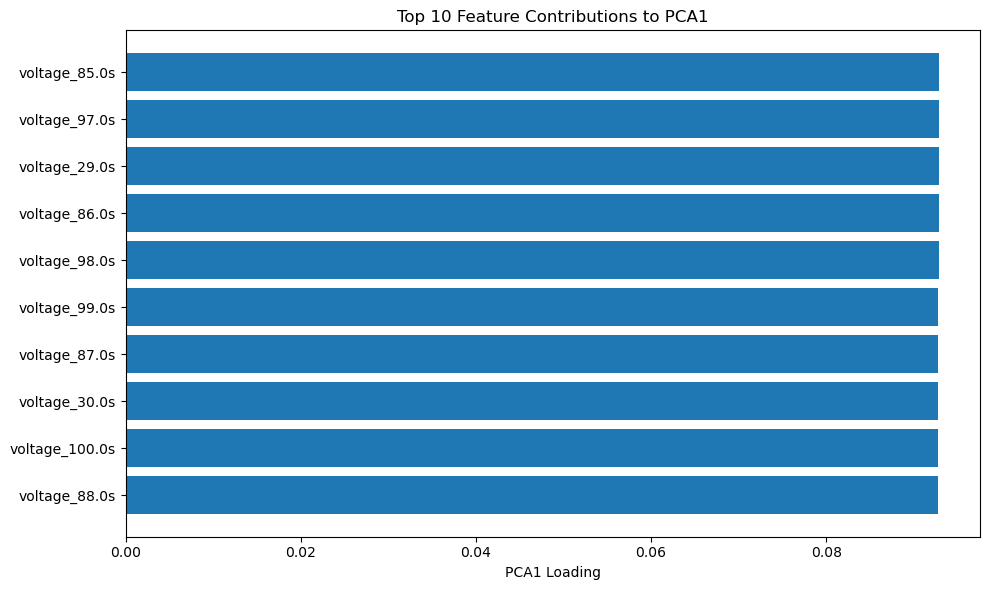

In [234]:
# Getting PCA1 loadings
pca1_loadings = pca.components_[0]

# Creating DataFrame with feature names and loadings
pca1_df = pd.DataFrame({
    'Feature': voltage_columns,
    'PCA1 Loading': pca1_loadings})

# Sortting by absolute loading values
pca1_df_sorted = pca1_df.reindex(pca1_df['PCA1 Loading'].abs().sort_values(ascending=False).index)

# Plot top 10 contributing features
plt.figure(figsize=(10, 6))
plt.barh(pca1_df_sorted['Feature'][:10], pca1_df_sorted['PCA1 Loading'][:10])
plt.xlabel('PCA1 Loading')
plt.title('Top 10 Feature Contributions to PCA1')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### Getting PCA1 acutal Values 

In [235]:
# PCA1 values for training data
pca1_values = X_train_pca[:, 0]

# Converting to DataFrame to check
pca1_values_df = pd.DataFrame(pca1_values, columns=['PCA1'])

print(pca1_values_df.head())


        PCA1
0  -0.291367
1 -20.050378
2  -2.514839
3  -7.000959
4  15.800790


#### Visualizing PCA1 vs Temperature

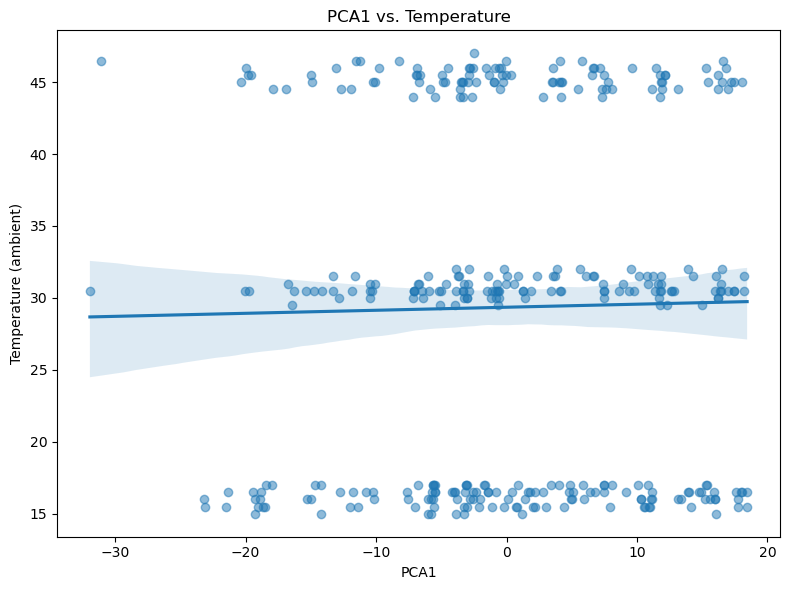

In [236]:
# Getting PCA1 values for test set
pca1_test_values = X_test_pca[:, 0]

# Creating DataFrame for plotting
pca1_temp_df = pd.DataFrame({
    'PCA1': pca1_test_values,
    'Temperature': y_test.reset_index(drop=True)})

# Scatter plot with regression line
plt.figure(figsize=(8, 6))
sns.regplot(data=pca1_temp_df, x='PCA1', y='Temperature', scatter_kws={'alpha':0.5})
plt.title('PCA1 vs. Temperature')
plt.xlabel('PCA1')
plt.ylabel('Temperature (ambient)')
plt.tight_layout()
plt.show()


#### voltage_soc_C

In [237]:
# defining features and target
X = voltage_soc_C.copy()
y = new_data_C.loc[X.index, 'temperature_ambient']  # Ensuring alignment

# Training-testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Linear Regression Model - (voltage + SOC)

In [238]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, lr_preds))
print("R² Score:", r2_score(y_test, lr_preds))

Linear Regression:
MSE: 148.4397344496304
R² Score: -0.07505498846544567


#### Random Forest Model - (voltage + SOC)

In [239]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


print("\nRandom Forest:")
print("MSE:", mean_squared_error(y_test, rf_preds))
print("R² Score:", r2_score(y_test, rf_preds))


Random Forest:
MSE: 74.29578257790368
R² Score: 0.46192269894269955


#### True vs Predicted Plots (Random Forest Model - (voltage + SOC))

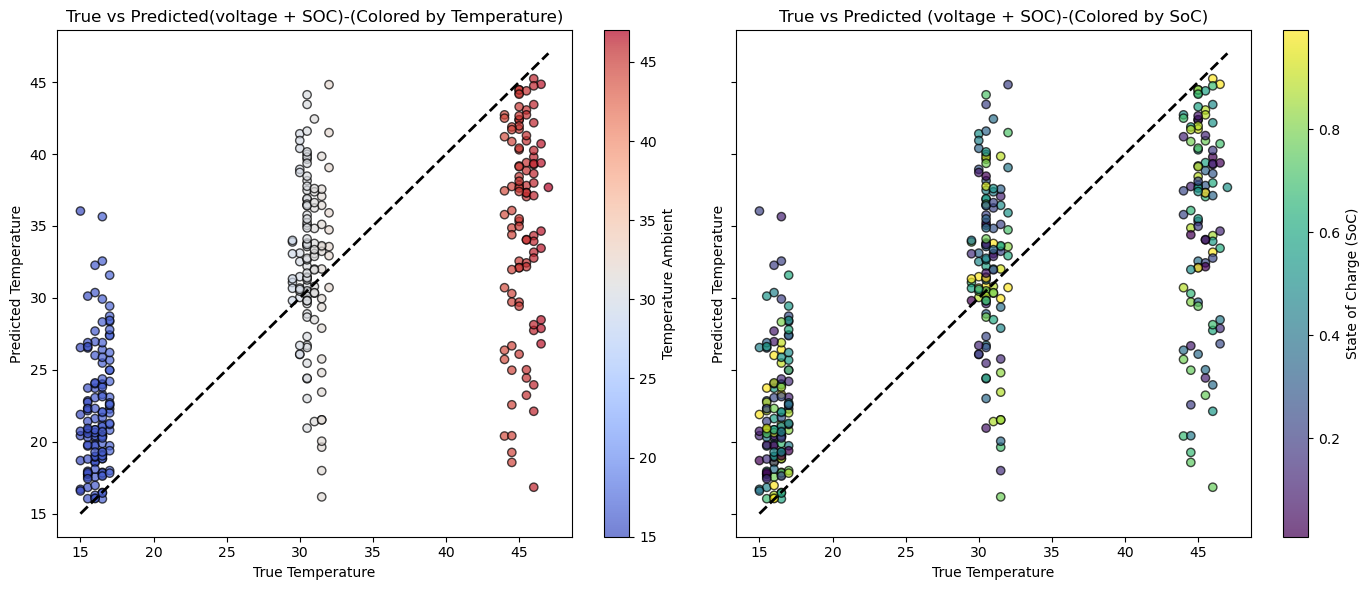

In [240]:
# Visualizing  setup
temperature = y_test.reset_index(drop=True)
soc = X_test['soc'].reset_index(drop=True)
residuals = y_test.reset_index(drop=True) - rf_preds

# Creating DataFrame for plotting
results_df = pd.DataFrame({
    'True Temperature': y_test.reset_index(drop=True),
    'Predicted Temperature': rf_preds,
    'Residuals': residuals,
    'Temperature Ambient': temperature,
    'SoC': soc})

# True vs Predicted Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Plot 1: Colored by Temperature
sc1 = axes[0].scatter(results_df['True Temperature'], results_df['Predicted Temperature'], c=results_df['Temperature Ambient'], cmap='coolwarm', 
                      edgecolor='k', alpha=0.7)
axes[0].plot([results_df['True Temperature'].min(), results_df['True Temperature'].max()],
             [results_df['True Temperature'].min(), results_df['True Temperature'].max()], 'k--', lw=2)
axes[0].set_title('True vs Predicted(voltage + SOC)-(Colored by Temperature)')
axes[0].set_xlabel('True Temperature')
axes[0].set_ylabel('Predicted Temperature')
cbar1 = fig.colorbar(sc1, ax=axes[0])
cbar1.set_label('Temperature Ambient')

# Plot 2: Colored by SoC
sc2 = axes[1].scatter(results_df['True Temperature'], results_df['Predicted Temperature'], c=results_df['SoC'], cmap='viridis', edgecolor='k', 
                      alpha=0.7)
axes[1].plot([results_df['True Temperature'].min(), results_df['True Temperature'].max()],
             [results_df['True Temperature'].min(), results_df['True Temperature'].max()], 'k--', lw=2)
axes[1].set_title('True vs Predicted (voltage + SOC)-(Colored by SoC)')
axes[1].set_xlabel('True Temperature')
axes[1].set_ylabel('Predicted Temperature')
cbar2 = fig.colorbar(sc2, ax=axes[1])
cbar2.set_label('State of Charge (SoC)')

plt.tight_layout()
plt.show()

#### Residual Plots (Random Forest Model - (voltage + SOC))

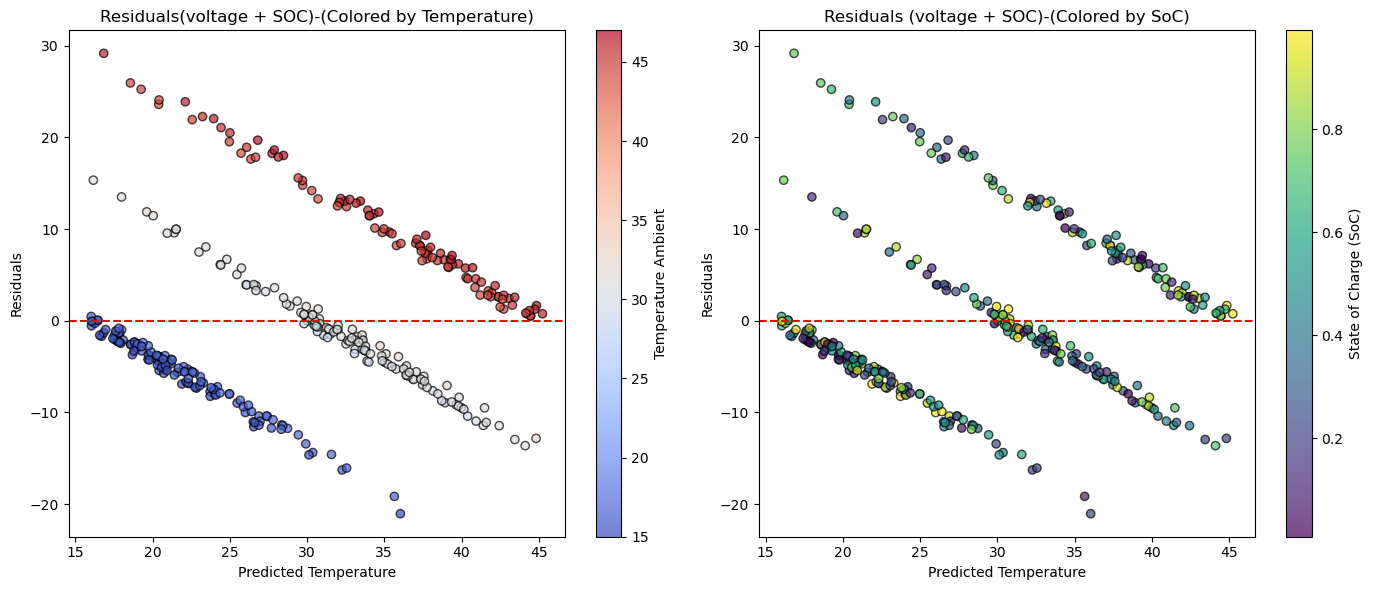

In [241]:
# Residual Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Residuals colored by Temperature
sc3 = axes[0].scatter(results_df['Predicted Temperature'], results_df['Residuals'], c=results_df['Temperature Ambient'], cmap='coolwarm', 
                      edgecolor='k', alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals(voltage + SOC)-(Colored by Temperature)')
axes[0].set_xlabel('Predicted Temperature')
axes[0].set_ylabel('Residuals')
cbar3 = fig.colorbar(sc3, ax=axes[0])
cbar3.set_label('Temperature Ambient')

# Residuals colored by SoC
sc4 = axes[1].scatter(results_df['Predicted Temperature'], results_df['Residuals'], c=results_df['SoC'], cmap='viridis', edgecolor='k', alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals (voltage + SOC)-(Colored by SoC)')
axes[1].set_xlabel('Predicted Temperature')
axes[1].set_ylabel('Residuals')
cbar4 = fig.colorbar(sc4, ax=axes[1])
cbar4.set_label('State of Charge (SoC)')

plt.tight_layout()
plt.show()

### PCA 

In [242]:
# Standardizing features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fitting PCA to retain 95% of variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Number of components chosen:", pca.n_components_)
print("Explained variance ratio:", pca.explained_variance_ratio_)


Number of components chosen: 2
Explained variance ratio: [0.94880241 0.04717515]


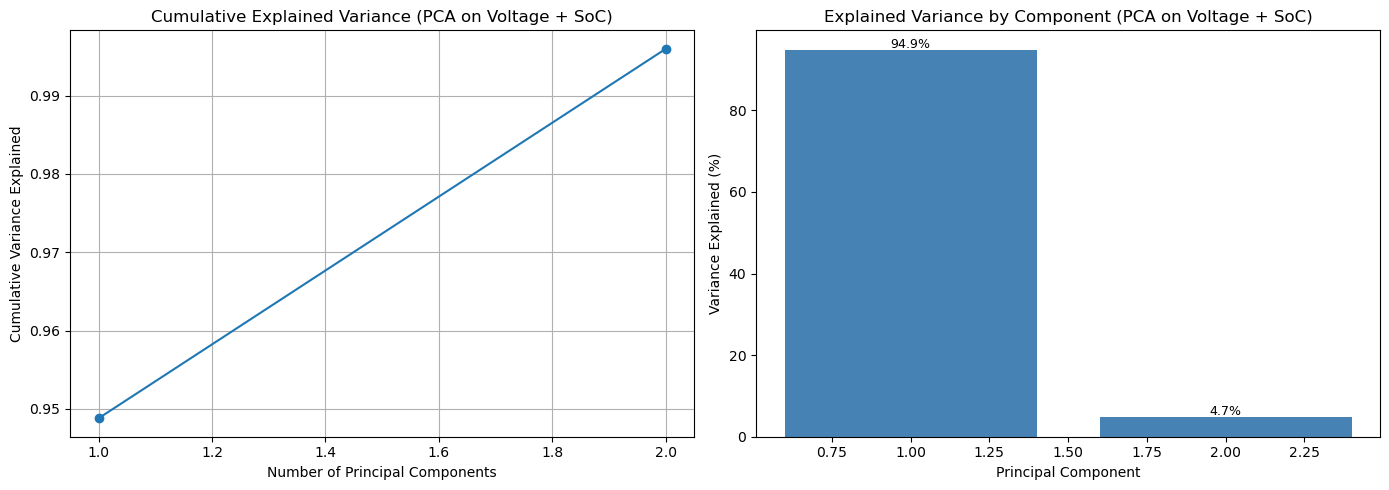

In [243]:
# Getting explained variance ratios
explained_var = pca.explained_variance_ratio_

# Creating subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative explained variance
axes[0].plot(range(1, len(explained_var) + 1), np.cumsum(explained_var), marker='o', linestyle='-')
axes[0].set_title('Cumulative Explained Variance (PCA on Voltage + SoC)')
axes[0].set_xlabel('Number of Principal Components')
axes[0].set_ylabel('Cumulative Variance Explained')
axes[0].grid(True)

# Plot 2: Individual explained variance
axes[1].bar(range(1, len(explained_var) + 1), explained_var * 100, color='steelblue')
axes[1].set_title('Explained Variance by Component (PCA on Voltage + SoC)')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained (%)')

# Adding percentage labels
for i, v in enumerate(explained_var * 100, start=1):axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


####  Linear Regression on PCA-Transformed Data

In [244]:
# Training Linear Regression on PCA-transformed data
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
lr_pca_preds = lr_pca.predict(X_test_pca)

# Evaluating
print("Linear Regression (PCA):")
print("MSE:", mean_squared_error(y_test, lr_pca_preds))
print("R² Score:", r2_score(y_test, lr_pca_preds))


Linear Regression (PCA):
MSE: 139.8608406197584
R² Score: -0.012923493542508657


#### Dummy Regressor

In [245]:
# Training Dummy Regressor (predicts the mean of y_train)
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

# Predictting on test set
y_pred_dummy = dummy.predict(X_test)

# Evaluating
mse_dummy = mean_squared_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mse_dummy)
r2_dummy = r2_score(y_test, y_pred_dummy)

print("Dummy Regressor (Mean Strategy)")
print("RMSE:", rmse_dummy)
print("R² Score:", r2_dummy)


Dummy Regressor (Mean Strategy)
RMSE: 11.775997471784459
R² Score: -0.004328801983158215


#### comparsion between all the models for (voltage + SOC)

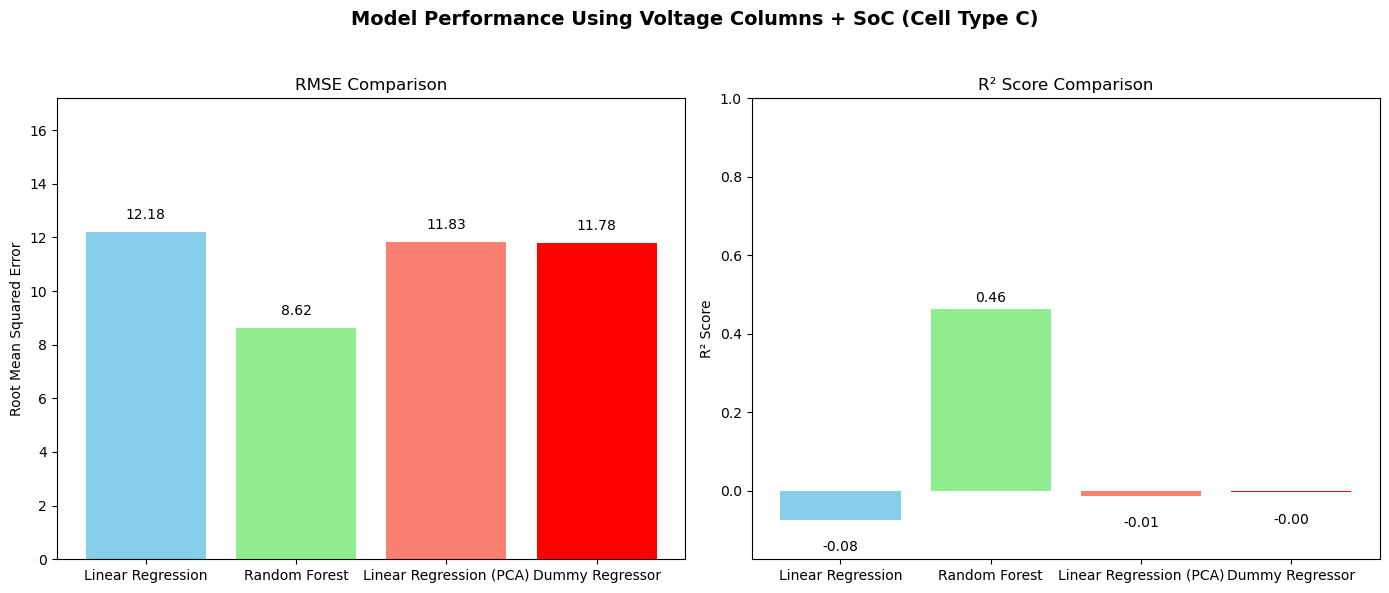

In [246]:

# Model names
models = ['Linear Regression', 'Random Forest', 'Linear Regression (PCA)', 'Dummy Regressor']

# RMSE values 
rmse_values = [148.4397344496304**.5, 74.29578257790368**.5, 139.8608406197584**.5,  11.775997471784459]

# R² values
r2_values = [-0.0751, 0.4619, -0.0129, -0.0043]

# Colors for each bar
colors = ['skyblue', 'lightgreen', 'salmon', 'red']

# Creating subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Performance Using Voltage Columns + SoC (Cell Type C)', fontsize=14, fontweight='bold')

# Plot 1: RMSE 
bars1 = axes[0].bar(models, rmse_values, color=colors)
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('Root Mean Squared Error')
axes[0].set_ylim(0, max(rmse_values) + 5)

# Adding value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{height:.2f}", ha='center', fontsize=10)

# Plot 2: R² Score 
bars2 = axes[1].bar(models, r2_values, color=colors)
axes[1].set_title('R² Score Comparison')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(min(r2_values) - 0.1, 1)

# Adding value labels
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, height + 0.02 if height >= 0 else height - 0.08, f"{height:.2f}", ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit title
plt.show()
